In [ ]:
import os
import sys
# set gpu to be pci bus id
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional
from sklearn.model_selection import train_test_split


In [3]:
# sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer
from sensor_modules import SensorModule
from reconstruction_modules import WienerDeconv, UNetDeconv, UNetDeconv_small

2026-04-28 22:41:27.216625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777416087.233040 1056660 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777416087.238511 1056660 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/juliama/miniconda3/envs/waller_env/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:85: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: T

In [4]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    sensor_module: eqx.Module
    reconstruction_module: eqx.Module
    use_adjoint_input: bool = eqx.field(static=True)

    def __init__(self, 
                 psf_module,
                 sensor_module,
                 reconstruction_module,
                 use_adjoint_input=False):
        
        self.psf_module = psf_module
        self.sensor_module = sensor_module
        self.reconstruction_module = reconstruction_module
        self.use_adjoint_input = use_adjoint_input
        

    def __call__(self, x: jnp.ndarray, key: Optional[jax.random.PRNGKey] = None, ensure_positive=True) -> tuple:
        # x: (B, H, W)
        key = jax.random.PRNGKey(0) if key is None else key # TODO: ask claude, is this bad seeding?
        psf, y = self.psf_module(x)  # psf:(K, L), y:(B, H, W)
        noisy_y = self.sensor_module(y, key=key, ensure_positive=ensure_positive)

        if self.use_adjoint_input:
            if self.sensor_module.sensor_array_enabled:
                sensor_mask = self.sensor_module.create_sensor_array()
            else:
                sensor_mask = jnp.ones_like(noisy_y[0])

            # Backproject the measurement into object coordinates.
            backprojection = self.psf_module.adjoint2D(psf, noisy_y)

            # A^T 1 is the object-space sensitivity of the active sensors.
            sensitivity = self.psf_module.adjoint2D(
                psf, sensor_mask[None, ...]
            )[0]
            sensitivity_max = jnp.max(sensitivity)
            denominator_floor = 0.05 * sensitivity_max + 1e-6
            normalized_backprojection = backprojection / jnp.maximum(
                sensitivity[None, ...], denominator_floor
            )
            normalized_sensitivity = sensitivity / (sensitivity_max + 1e-6)
            sensitivity_batch = jnp.broadcast_to(
                normalized_sensitivity[None, ...], backprojection.shape
            )

            # U-Net input shape: (B, 2, H, W).
            reconstruction_input = jnp.stack(
                [normalized_backprojection, sensitivity_batch], axis=1
            )
        else:
            reconstruction_input = noisy_y

        x_hat = self.reconstruction_module(reconstruction_input, psf) # (B, H, W)
        
        return x_hat, noisy_y, psf

In [ ]:
# general
seed_value = 42 #TODO: FIX SEEDING
key = jax.random.PRNGKey(seed_value)

# loading images
tile_rows=3
tile_cols=3
batch_size=32  
dataset_name = 'mnist'
photon_count = 160
subset_fraction = 0.9

# psf stuff constants
lr_psf_means = 6.4161e-2
lr_psf_covs = 1.6032e-4
lr_psf_weights = 4.2456e-4
psf_size = (96, 96)
object_size = 32
num_gaussians = 10
use_ideal = False

# sensor stuff
noise_enabled = True
sensor_array_enabled = True
gaussian_sigma = 0.5

sensor_array_params = {
    "H": 96,
    "W": 96, 
    "rows": 2,
    "cols": 1,
    "sensor_h": 15,
    "sensor_w": 15,
    "spacing_y": 20,
    "spacing_x": 0
}

# recon stuff
recon_name = 'unet'
log_K = jnp.array(-4.0) #initial starting K value for wiener deconv
lr_recon = 8.2019e-4

# train stuff
num_steps = 10000
visualize_every = 100

#wandb logging stuff
use_wandb = True
project_name = 'e2e_imaging'
run_name = f'combined_recon_two_sensor_{dataset_name}_recon_{recon_name}_ideal_init_{use_ideal}_gaussian_sigma_{gaussian_sigma}_photon_count_{photon_count}_num_gaussian_{num_gaussians}'
log_every = 25

In [6]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
        'num_steps': num_steps
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer_module': {
        'lr_psf_means': lr_psf_means,
        'lr_psf_covs': lr_psf_covs,
        'lr_psf_weights': lr_psf_weights,
        'object_size': object_size,
        'num_gaussians': num_gaussians,
        'psf_size': psf_size,
        'gaussian_sigma': gaussian_sigma,
        'use_ideal': use_ideal
    },

    'sensor_module': {
        'noise_enabled': noise_enabled,
        'sensor_array_enabled': sensor_array_enabled, 
        'gaussian_sigma': gaussian_sigma,
        'sensor_array_params': sensor_array_params
    },

    'reconstruction_module': {
        'recon_name': recon_name,
        'initial log_K': log_K,
        'lr_recon': lr_recon
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
        'visualize_every': visualize_every
    }
}

In [8]:
# load images!
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)

if dataset_name == 'cifar10':
    x_data, x_test = data_generator.load_cifar10_data()
elif dataset_name == 'mnist':
    x_data, x_test = data_generator.load_mnist_data()

x_train, x_val = train_test_split(x_data, test_size=0.1, random_state=seed_value)
train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)
val_dataset = data_generator.create_dataset(x_val, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)
test_dataset =  data_generator.create_dataset(x_test, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)


print("x_train range:", x_train.min(), x_train.max(), x_train.mean())
print("x_val range:",   x_val.min(),   x_val.max(),   x_val.mean())
print("x_test range:",  x_test.min(),  x_test.max(),  x_test.mean())


2026-04-28 07:52:19.831091: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1777362739.831585  691542 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9798 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:89:00.0, compute capability: 7.5


x_train range: 0.0 1.0 0.100058556
x_val range: 0.0 1.0 0.10024682
x_test range: 0.0 1.0 0.1011519


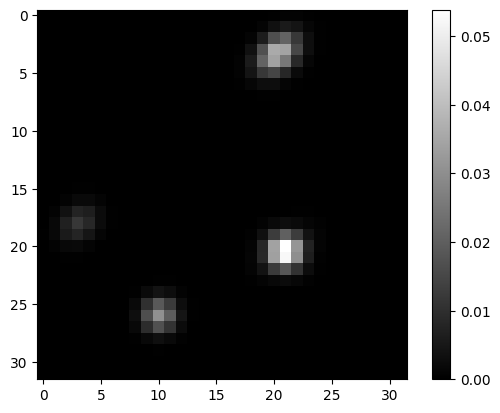

In [ ]:
# the model (psf layer)
key_1, subkey_1 = jax.random.split(key) # TODO: replace this with self.next_rng_key()??
psf_module = RMLPSFLayer(object_size=96, num_gaussians=num_gaussians, psf_size=psf_size, key=subkey_1)

if use_ideal:
    params = np.load("/home/juliama/wallerlab/e2e-imaging/ideal_psfs/two_square_sensor_array_reint_pixel_cnn_FALSE_0.1_loss_patch_16_reinitializing_refit_pixelcnn_patience_20_lr_5_steps_per_epoch_0.0001_init_100_optimized_psf_params.npz")

    psf_module = eqx.tree_at(
        lambda m: (m.means, m.covs, m.weights),
        psf_module,
        (
            jnp.array(params['means']),
            jnp.array(params['covs']),
            jnp.array(params['weights'])
        )
    )

# visualize it
plt.imshow(psf_module.compute_psf(), cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
# the model cont.
key_2, subkey_2 = jax.random.split(key_1)
key_3, subkey_3 = jax.random.split(key_2)

# psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
sensor_module = SensorModule(photon_count=photon_count, 
                             noise_enabled=noise_enabled,
                             sensor_array_enabled=sensor_array_enabled, 
                             gaussian_sigma=gaussian_sigma, 
                             sensor_array_params= sensor_array_params)

if recon_name == 'wiener':
    reconstruction_module = WienerDeconv(log_K)
if recon_name == 'unet':
    reconstruction_module = UNetDeconv(in_channels=2, key=subkey_2)
if recon_name == 'unet_small':
    reconstruction_module = UNetDeconv_small(in_channels=2, key=subkey_2)

model = E2E(
    psf_module=psf_module,
    sensor_module=sensor_module,
    reconstruction_module=reconstruction_module,
    use_adjoint_input=recon_name in ('unet', 'unet_small'),
)
plt.imshow(model.sensor_module.create_sensor_array(), cmap='gray')
plt.axis('off')
plt.show()

KeyboardInterrupt: 

In [ ]:
e2e_optimizer = E2EOptimizer(
    model=model,
    lr_psf_means=lr_psf_means,
    lr_psf_covs=lr_psf_covs,
    lr_psf_weights=lr_psf_weights,
    lr_recon=lr_recon,
    use_wandb=use_wandb, 
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config,
    val_dataset=val_dataset,
    test_dataset=test_dataset
)

In [ ]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=num_steps,
    log_every=log_every,
    visualize_every=visualize_every,
    key=subkey_3
)

In [ ]:
# key_4, subkey_4 = jax.random.split(key_3)
# key_5, subkey_5 = jax.random.split(key_4)

# # Phase 1: freeze weights, let means/covs settle
# optimizer1 = E2EOptimizer(
#     model=model,
#     lr_psf_means=lr_psf_means,
#     lr_psf_covs=lr_psf_covs,
#     lr_recon=lr_recon,
#     use_wandb=False, 
#     project_name='e2e_imaging_playground',
#     run_name=run_name,
#     wandb_config=wandb_config,
#     val_dataset=val_dataset,
#     test_dataset=test_dataset,
#     freeze_psf_weights=True
# )
# model = optimizer1.optimize(
#     train_dataset,
#     num_steps=200,
#     log_every=10,
#     visualize_every=20,
#     key=subkey_4
# )

# optimizer2 = E2EOptimizer(
#     model=model,
#     lr_psf_means=lr_psf_means,
#     lr_psf_covs=lr_psf_covs,
#     lr_psf_weights=lr_psf_weights,
#     lr_recon=lr_recon,
#     use_wandb=True, 
#     project_name='e2e_imaging_playground',
#     run_name=run_name,
#     wandb_config=wandb_config,
#     val_dataset=val_dataset,
#     test_dataset=test_dataset
# )
# # Phase 2: unfreeze weights with a small LR
# optimized_imaging_system = optimizer2.optimize(
#     train_dataset,
#     num_steps=800,
#     log_every=10,
#     visualize_every=20,
#     key=subkey_5
# )

NameError: name 'E2EOptimizer' is not defined